# Tree-Based Modeling Across Healthcare Datasets

This notebook applies tree-based machine learning models across three healthcare-related datasets: diabetes, life expectancy, and SUPPORT2. The workflow includes decision tree and random forest modeling, cross-validation, hyperparameter tuning, pruning review, and model-performance comparison.

The classification tasks are evaluated primarily with balanced accuracy and log loss because the healthcare outcome classes are imbalanced. The regression task is evaluated with RMSE and MAE to measure prediction error for life expectancy.

This notebook is included in the modeling folder because the main focus is model development, parameter tuning, and performance evaluation rather than exploratory data analysis.

## Diabetes Dataset: Decision Tree Classification

This section applies decision tree classification to the diabetes dataset. The target variable is the first column, and the workflow tests tree depth, minimum leaf size, and pruning strength using cross-validation.

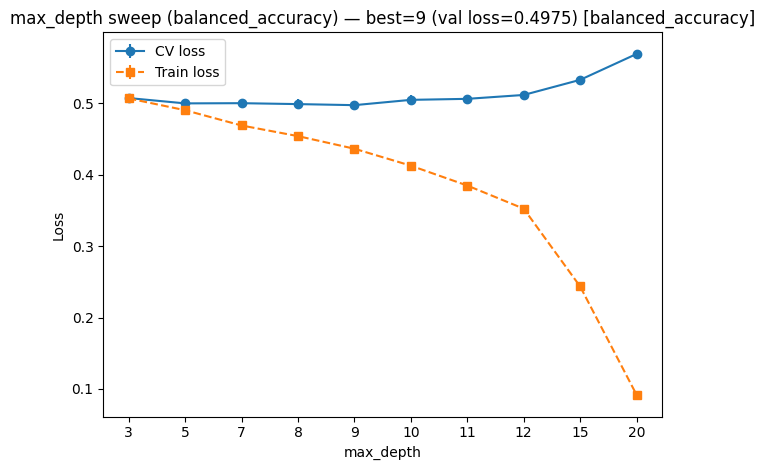

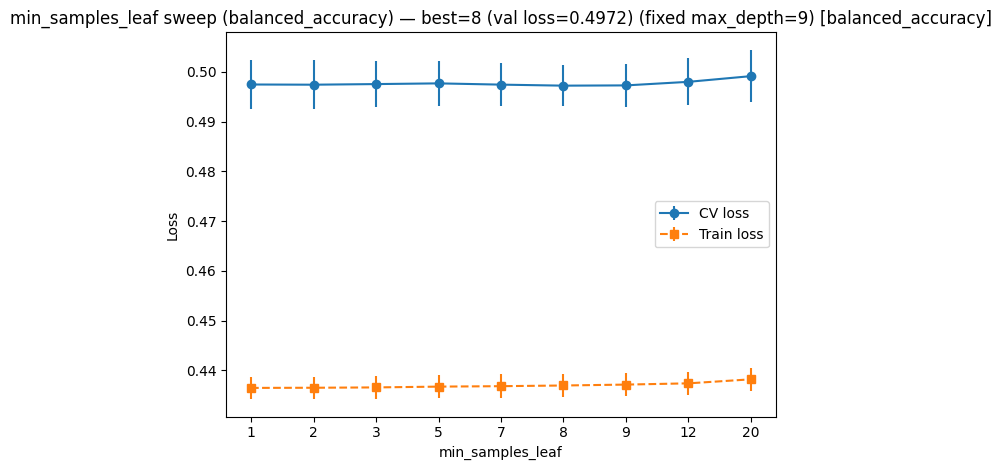

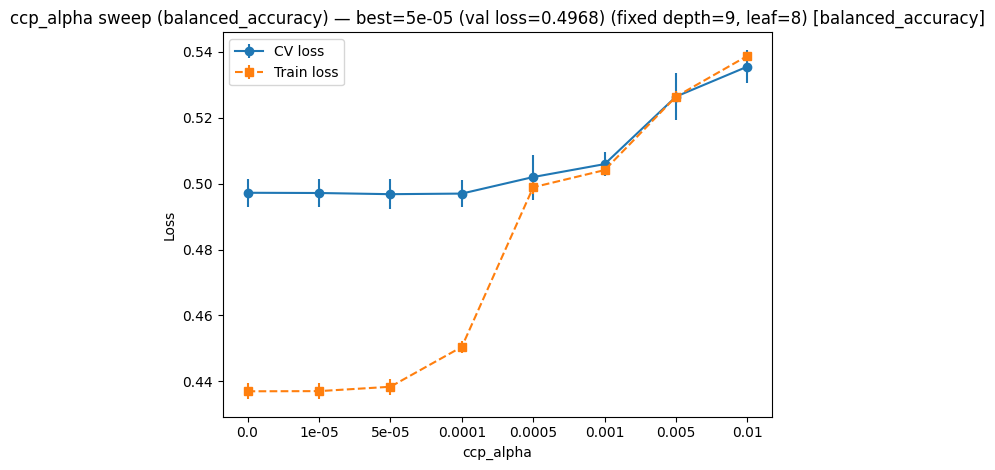


Chosen parameters (first column as target):
  max_depth        = 9
  min_samples_leaf = 8
  ccp_alpha        = 5e-05

Final 5-fold CV metrics:
  balanced_accuracy = 0.5032  (higher is better)
  log_loss          = 0.9107  (lower is better)


In [51]:
# Decision Tree: One-Parameter-at-a-Time tuning on BRFSS Diabetes (fitst column = target)
# metric: balanced_accuracy (higher is better; plot loss = 1 - score)
# reports log_loss (lower is better) for probability quality
# Order: max_depth -> min_samples_leaf -> ccp_alpha (post-pruning)
# class_weight="balanced" to handle label imbalance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, validation_curve, cross_val_score
from sklearn.utils.multiclass import type_of_target

#setup
csv_path    = "diabetes_012_health_indicators_BRFSS2015.csv"  
n_splits    = 5
random_seed = 42
n_jobs      = -1   

#load and target
df = pd.read_csv(csv_path)
target_col = df.columns[0]    #first column is the target
y = df[target_col].values
X = df.drop(columns=[target_col])

#checks / prep
if type_of_target(y) not in ("binary", "multiclass"):
    raise ValueError(f"Target looks non-classification: {type_of_target(y)}")

# DecisionTree needs numeric and no NaNs
X = X.apply(pd.to_numeric, errors="coerce")
if X.isna().any().any():
    X = X.fillna(X.median())

# CV splitter
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

# Base model
base_tree = DecisionTreeClassifier(random_state=random_seed, class_weight="balanced")


def param_curve(estimator, X, y, *, param_name, param_values, scoring, cv, title_note=""):
   
    tr_scores, va_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_values,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs
    )
    tr_mean, va_mean = tr_scores.mean(axis=1), va_scores.mean(axis=1)
    tr_std,  va_std  = tr_scores.std(axis=1),  va_scores.std(axis=1)

    is_neg = isinstance(scoring, str) and scoring.startswith("neg_")
    tr_loss  = (-tr_mean) if is_neg else (1 - tr_mean)
    va_loss  = (-va_mean) if is_neg else (1 - va_mean)

    best_idx   = int(np.argmin(va_loss))
    best_param = param_values[best_idx]
    best_loss  = float(va_loss[best_idx])

    # Plot
    plt.figure()
    x = np.arange(len(param_values))
    plt.errorbar(x, va_loss, yerr=va_std, fmt="o-", label="CV loss")
    plt.errorbar(x, tr_loss, yerr=tr_std, fmt="s--", label="Train loss")
    plt.xticks(x, [str(v) for v in param_values])
    plt.xlabel(param_name); plt.ylabel("Loss")
    plt.title(f"{param_name} sweep ({scoring}) — best={best_param} (val loss={best_loss:.4f}) {title_note}")
    plt.legend(); plt.tight_layout(); plt.show()

    # Return results
    res = pd.DataFrame({
        "param_value": param_values,
        "train_score": tr_mean,
        "val_score": va_mean,
        "val_loss": va_loss
    })

    return {"best_param": best_param, "best_val_loss": best_loss, "results": res}

# Tune max_depth (strongest overfitting control)
depth_values = [3, 5, 7, 8, 9, 10, 11, 12, 15, 20]  
res_depth = param_curve(
    base_tree, X, y,
    param_name="max_depth",
    param_values=depth_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note="[balanced_accuracy]"
)
best_depth = res_depth["best_param"]

#Tune min_samples_leaf
leaf_values = [1, 2, 3, 5, 7, 8, 9, 12, 20]
tree_d = base_tree.set_params(max_depth=best_depth)
res_leaf = param_curve(
    tree_d, X, y,
    param_name="min_samples_leaf",
    param_values=leaf_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note=f"(fixed max_depth={best_depth}) [balanced_accuracy]"
)
best_leaf = res_leaf["best_param"]

#Tune ccp_alpha
alpha_values = [0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
tree_dl = base_tree.set_params(max_depth=best_depth, min_samples_leaf=best_leaf)
res_alpha = param_curve(
    tree_dl, X, y,
    param_name="ccp_alpha",
    param_values=alpha_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note=f"(fixed depth={best_depth}, leaf={best_leaf}) [balanced_accuracy]"
)
best_alpha = res_alpha["best_param"]

# Final cross-validated metrics with chosen params
final_tree = base_tree.set_params(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    ccp_alpha=best_alpha
)

final_bal_acc = cross_val_score(final_tree, X, y, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs).mean()
final_logloss  = -cross_val_score(final_tree, X, y, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs).mean()

print("\nChosen parameters (first column as target):")
print(f"  max_depth        = {best_depth}")
print(f"  min_samples_leaf = {best_leaf}")
print(f"  ccp_alpha        = {best_alpha}")
print("\nFinal 5-fold CV metrics:")
print(f"  balanced_accuracy = {final_bal_acc:.4f}  (higher is better)")
print(f"  log_loss          = {final_logloss:.4f}  (lower is better)")

# Save numeric results to CSV for auditability
save_csvs = True
if save_csvs:
    res_depth["results"].to_csv("dt_depth_balanced_accuracy.csv", index=False)
    res_leaf["results"].to_csv("dt_leaf_balanced_accuracy.csv", index=False)
    res_alpha["results"].to_csv("dt_alpha_balanced_accuracy.csv", index=False)
    pd.DataFrame({
        "param": ["max_depth"] * len(depth_values) + ["min_samples_leaf"] * len(leaf_values) + ["ccp_alpha"] * len(alpha_values),
        "value": depth_values + leaf_values + alpha_values
    }).to_csv("dt_grids.csv", index=False)

In [52]:
# decision tree (classification): grid search for diabetes_012
# target: first column (diabetes_012)
# metrics: balanced_accuracy (primary), log_loss (secondary)
# 3-fold cv, small grid, parallel jobs, subsample for the search

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score

#setup
csv_path      = "diabetes_012_health_indicators_BRFSS2015.csv"
random_seed   = 42
n_splits      = 3          
n_jobs        = -1        
use_subsample = True       
sub_rows      = 50000     

# small grid
param_grid = {
    "max_depth":        [5, 7, 9],
    "min_samples_leaf": [1, 2, 5, 8],
    "ccp_alpha":        [0.0, 1e-5, 5e-5, 1e-4]
}

# load and prep
df = pd.read_csv(csv_path)

target_col = df.columns[0]
y_full = df[target_col].astype(int).values
x_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")
x_full = x_full.fillna(x_full.median(numeric_only=True)).astype("float32")

#subsample for the grid search (final cv uses full data)
if use_subsample and len(x_full) > sub_rows:
    x_s, _, y_s, _ = train_test_split(
        x_full, y_full, train_size=sub_rows, stratify=y_full, random_state=random_seed
    )
else:
    x_s, y_s = x_full, y_full

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

# grid search
tree = DecisionTreeClassifier(random_state=random_seed, class_weight="balanced")

scoring = {"ba": "balanced_accuracy", "logloss": "neg_log_loss"}

gs = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring=scoring,
    refit="ba",     
    cv=cv,
    n_jobs=n_jobs,
    verbose=1
)

gs.fit(x_s, y_s)

# show top 10 by balanced_accuracy
cvres = pd.DataFrame(gs.cv_results_).copy()
cvres["mean_ba"]      = cvres["mean_test_ba"]
cvres["std_ba"]       = cvres["std_test_ba"]
cvres["mean_logloss"] = -cvres["mean_test_logloss"]  
cvres["std_logloss"]  =  cvres["std_test_logloss"]

cols = [
    "rank_test_ba", "mean_ba", "std_ba", "mean_logloss", "std_logloss",
    "param_max_depth", "param_min_samples_leaf", "param_ccp_alpha"
]
cvres_sorted = cvres.sort_values("rank_test_ba").reset_index(drop=True)
top10 = cvres_sorted.loc[:9, cols]

print("\n top 10 parameter sets (by balanced_accuracy):")
print(top10.to_string(index=False))

#save the full table
cvres_sorted.to_csv("dt_grid_results_diabetes012_light.csv", index=False)
print("\n saved full grid results to dt_grid_results_diabetes012_light.csv")

# final evaluation on full data with best params
best_params = gs.best_params_
print("\nbest params (by cv balanced_accuracy):", best_params)

best_tree = DecisionTreeClassifier(
    random_state=random_seed,      
    class_weight="balanced",
    **best_params
)

ba_full = cross_val_score(
    best_tree, x_full, y_full, cv=cv,
    scoring="balanced_accuracy", n_jobs=n_jobs
).mean()

logloss_full = -cross_val_score(
    best_tree, x_full, y_full, cv=cv,
    scoring="neg_log_loss", n_jobs=n_jobs
).mean()

print(f"\nfinal {n_splits}-fold cv on full data -> balanced_accuracy={ba_full:.4f}, log_loss={logloss_full:.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits

 top 10 parameter sets (by balanced_accuracy):
 rank_test_ba  mean_ba   std_ba  mean_logloss  std_logloss  param_max_depth  param_min_samples_leaf  param_ccp_alpha
            1 0.483795 0.004598      0.961693     0.029499                7                       2          0.00010
            2 0.483763 0.004541      0.962257     0.029775                7                       1          0.00010
            3 0.483676 0.004513      0.959299     0.028043                7                       5          0.00010
            4 0.483309 0.004746      0.970749     0.027930                7                       5          0.00005
            5 0.483302 0.004743      0.971318     0.026995                7                       5          0.00001
            5 0.483302 0.004743      0.971318     0.026995                7                       5          0.00000
            7 0.483204 0.004622      0.975320     0.024284             

**Decision tree summary for diabetes:** The tuned decision tree provides a baseline tree-based classification model for the diabetes outcome. Balanced accuracy and log loss are used to evaluate performance because the diabetes outcome classes are imbalanced.

## Life Expectancy Dataset: Decision Tree Regression

This section applies decision tree regression to the life expectancy dataset. The target variable is life expectancy, and the model is tuned using tree depth, minimum leaf size, and post-pruning strength.

Using target column: Life expectancy 
Dropping all-NaN columns: ['Country', 'Status']


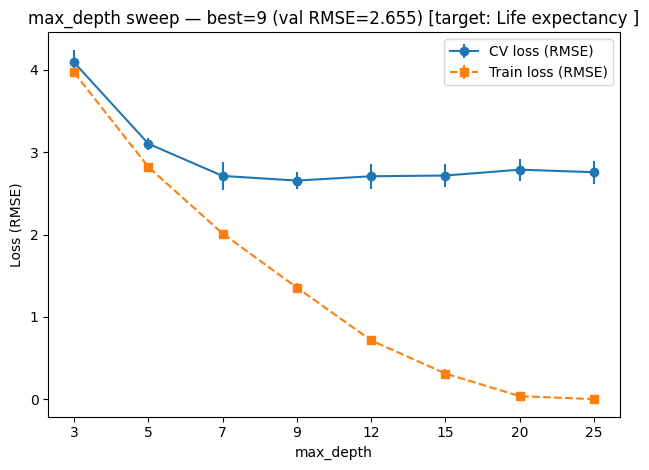

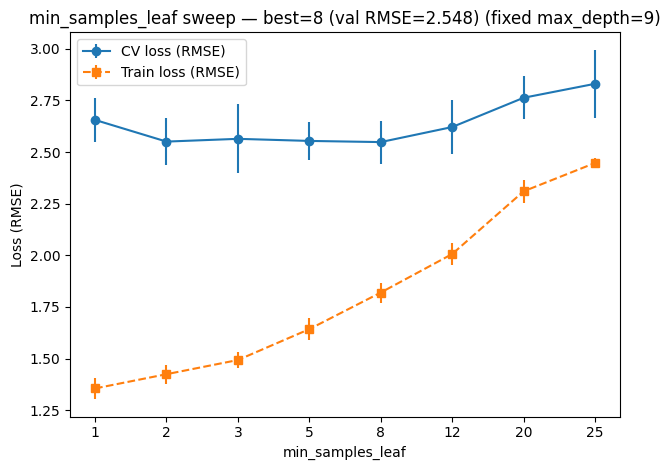

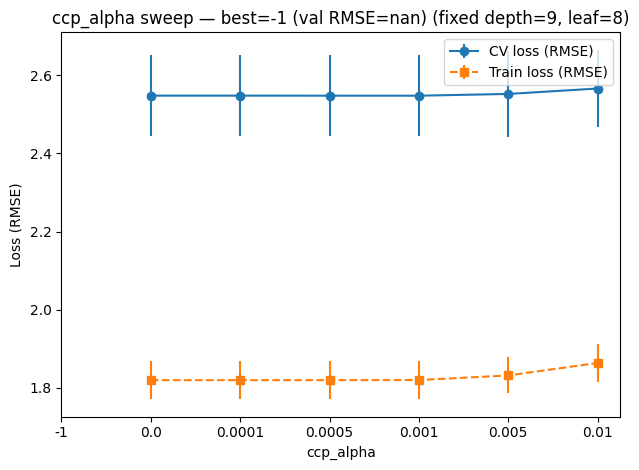


Chosen params:
  max_depth = 9
  min_samples_leaf = 8
  ccp_alpha = 0.0

Final 5-fold CV: RMSE=2.5481, MAE=1.7709


In [53]:
#Decision Tree (Regression) One-Parameter-at-a-Time tuning on Life Expectancy (imputed)
#Target column = D (4th column from left)
#Selection metric: RMSE via "neg_root_mean_squared_error" (plot RMSE as loss)
#Also reports MAE
#Order: max_depth -> min_samples_leaf -> ccp_alpha (post-pruning)
#NaN handling after numeric coercion

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, validation_curve, cross_val_score, train_test_split

#setup
csv_path    = "Life Expectancy Data - mean_mode_imputed.csv" 
n_splits    = 5        
random_seed = 42
n_jobs      = 1          

# Load & choose target (column D = 4th column)
df = pd.read_csv(csv_path)

target_IDX = 3                      #column D
target_col = df.columns[target_IDX]
print("Using target column:", target_col)

y = df[target_col].values
X = df.drop(columns=[target_col])


# Coerce everything to numeric; non-numeric entries become NaN
X = X.apply(pd.to_numeric, errors="coerce")

# Drop columns that are entirely NaN after coercion
all_nan_cols = [c for c in X.columns if X[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

# Fill remaining NaNs with column medians
X = X.fillna(X.median(numeric_only=True))

MAX_ROWS = None 
if MAX_ROWS is not None and len(X) > MAX_ROWS:
    X, _, y, _ = train_test_split(X, y, train_size=MAX_ROWS, random_state=random_seed)

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
base = DecisionTreeRegressor(random_state=random_seed)

#sweep a parameter and plot RMSE loss vs values
def param_curve(estimator, X, y, *, param_name, param_values, scoring, cv, title_note=""):
   
    tr_scores, va_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_values,
        scoring=scoring,      
        cv=cv,
        n_jobs=n_jobs
    )
    tr_mean, va_mean = tr_scores.mean(axis=1), va_scores.mean(axis=1)
    tr_std,  va_std  = tr_scores.std(axis=1),  va_scores.std(axis=1)

    # Convert to positive loss for plotting
    is_neg = isinstance(scoring, str) and scoring.startswith("neg_")
    tr_loss = (-tr_mean) if is_neg else (1 - tr_mean)
    va_loss = (-va_mean) if is_neg else (1 - va_mean)

    best_idx   = int(np.argmin(va_loss))
    best_param = param_values[best_idx]
    best_loss  = float(va_loss[best_idx])

    # Plot 
    plt.figure()
    x = np.arange(len(param_values))
    plt.errorbar(x, va_loss, yerr=va_std, fmt="o-", label="CV loss (RMSE)")
    plt.errorbar(x, tr_loss, yerr=tr_std, fmt="s--", label="Train loss (RMSE)")
    plt.xticks(x, [str(v) for v in param_values])
    plt.xlabel(param_name)
    plt.ylabel("Loss (RMSE)")
    plt.title(f"{param_name} sweep — best={best_param} (val RMSE={best_loss:.3f}) {title_note}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "best_param": best_param,
        "best_val_loss": best_loss,
        "values": list(param_values),
        "val_loss": list(va_loss)
    }


#Tune max_depth
depth_values = [3, 5, 7, 9, 12, 15, 20, 25]
res_depth = param_curve(
    base, X, y,
    param_name="max_depth",
    param_values=depth_values,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    title_note=f"[target: {target_col}]"
)
best_depth = res_depth["best_param"]


#Tune min_samples_leaf
leaf_values = [1, 2, 3, 5, 8, 12, 20, 25]
res_leaf = param_curve(
    base.set_params(max_depth=best_depth), X, y,
    param_name="min_samples_leaf",
    param_values=leaf_values,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    title_note=f"(fixed max_depth={best_depth})"
)
best_leaf = res_leaf["best_param"]

#Tune ccp_alpha
alpha_values = [-1, 0.0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
res_alpha = param_curve(
    base.set_params(max_depth=best_depth, min_samples_leaf=best_leaf), X, y,
    param_name="ccp_alpha",
    param_values=alpha_values,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    title_note=f"(fixed depth={best_depth}, leaf={best_leaf})"
)
best_alpha = res_alpha["best_param"]

import numpy as np

best_alpha = float(res_alpha["best_param"])         
if not np.isfinite(best_alpha) or best_alpha < 0:
    best_alpha = 0.0

best_leaf_clean = int(best_leaf)                 
best_depth_clean = None if best_depth is None else int(best_depth)

# Final CV metrics (RMSE + MAE) with chosen params
final = base.set_params(max_depth=best_depth, min_samples_leaf=best_leaf, ccp_alpha=best_alpha)
cv_rmse = -cross_val_score(final, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=n_jobs).mean()
cv_mae  = -cross_val_score(final, X, y, cv=cv, scoring="neg_mean_absolute_error",   n_jobs=n_jobs).mean()

print("\nChosen params:")
print(f"  max_depth = {best_depth}")
print(f"  min_samples_leaf = {best_leaf}")
print(f"  ccp_alpha = {best_alpha}")
print(f"\nFinal {n_splits}-fold CV: RMSE={cv_rmse:.4f}, MAE={cv_mae:.4f}")

In [54]:
# decision tree (regression): grid search
# dataset: life expectancy (imputed)
# target: 4th column (column D)
# primary metric: rmse via "neg_root_mean_squared_error" 

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split

# configure
csv_path    = "Life Expectancy Data - mean_mode_imputed.csv"
random_seed = 42
n_splits    = 5     
n_jobs      = -1

# load & prep data
df = pd.read_csv(csv_path)
target_col = df.columns[3]  # 4th column
print("using target column:", target_col)

y_full = pd.to_numeric(df[target_col], errors="coerce").values
x_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")

# drop all-nan columns, fill remaining nans
drop_cols = [c for c in x_full.columns if x_full[c].isna().all()]
if drop_cols:
    print("dropping all-nan columns:", drop_cols)
    x_full = x_full.drop(columns=drop_cols)
x_full = x_full.fillna(x_full.median(numeric_only=True)).astype("float32")

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

# pruning alphas
n = len(x_full)

train_size = min(10000, max(1, n - 1))
x_alpha, _, y_alpha, _ = train_test_split(
    x_full, y_full, train_size=train_size, random_state=random_seed
)

temp_tree = DecisionTreeRegressor(random_state=random_seed)
path = temp_tree.cost_complexity_pruning_path(x_alpha, y_alpha)
alpha_candidates = np.unique(np.round(path.ccp_alphas, 7))

if len(alpha_candidates) > 20:
    qs = np.linspace(0.05, 0.95, 20)
    alpha_candidates = np.unique(np.quantile(alpha_candidates, qs))
alpha_candidates = [float(a) for a in alpha_candidates if np.isfinite(a)]

print(f"using {len(alpha_candidates)} ccp_alpha candidates from pruning path")

# grid focused on overfitting control
param_grid = {
    "max_depth":        [5, 7, 9, 11],
    "min_samples_leaf": [1, 3, 5, 8, 12],
    "ccp_alpha":        alpha_candidates
}

dt = DecisionTreeRegressor(random_state=random_seed)

gs = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # higher is better (neg rmse)
    refit=True,
    cv=cv,
    n_jobs=n_jobs,
    verbose=1
)

gs.fit(x_full, y_full)

# show top 10 by cv rmse
cvres = pd.DataFrame(gs.cv_results_).copy()
cvres["mean_rmse"] = -cvres["mean_test_score"]  # flip sign -> rmse
cvres["std_rmse"]  =  cvres["std_test_score"]

cols = [
    "rank_test_score", "mean_rmse", "std_rmse",
    "param_max_depth", "param_min_samples_leaf", "param_ccp_alpha"
]
cvres_sorted = cvres.sort_values("rank_test_score").reset_index(drop=True)
top10 = cvres_sorted.loc[:9, cols]

print("\n top 10 parameter sets (by cv rmse):")
print(top10.to_string(index=False))

# final cv metrics on full data with best params
best_params = gs.best_params_
print("\n best params (by cv rmse):", best_params)

best_tree = DecisionTreeRegressor(random_state=random_seed, **best_params)

rmse_full = -cross_val_score(
    best_tree, x_full, y_full, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=n_jobs
).mean()
mae_full  = -cross_val_score(
    best_tree, x_full, y_full, cv=cv, scoring="neg_mean_absolute_error", n_jobs=n_jobs
).mean()

print(f"\n final {n_splits}-fold cv on full data -> rmse={rmse_full:.4f}, mae={mae_full:.4f}")

using target column: Life expectancy 
dropping all-nan columns: ['Country', 'Status']
using 20 ccp_alpha candidates from pruning path
Fitting 5 folds for each of 400 candidates, totalling 2000 fits

 top 10 parameter sets (by cv rmse):
 rank_test_score  mean_rmse  std_rmse  param_max_depth  param_min_samples_leaf  param_ccp_alpha
               1   2.513983  0.126800               11                       8         0.001801
               2   2.514904  0.127619               11                       8         0.001322
               3   2.514939  0.129578               11                       8         0.004306
               4   2.515158  0.128382               11                       8         0.000564
               4   2.515158  0.128382               11                       8         0.000437
               6   2.515237  0.128462               11                       8         0.000211
               7   2.515249  0.128474               11                       8         0.000

**Decision tree summary for life expectancy:** The tuned decision tree regression model is evaluated using RMSE and MAE. These metrics show how closely the model predicts life expectancy after preprocessing and parameter tuning.

## SUPPORT2 Dataset: Decision Tree Classification

This section applies decision tree classification to the SUPPORT2 dataset, using death as the binary target outcome. The workflow evaluates tree complexity and pruning while accounting for class imbalance.

Using target column (3rd from right): death
Dropping all-NaN columns: ['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']


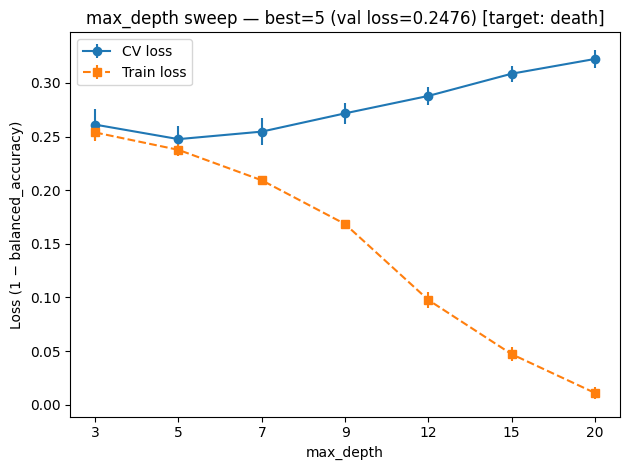

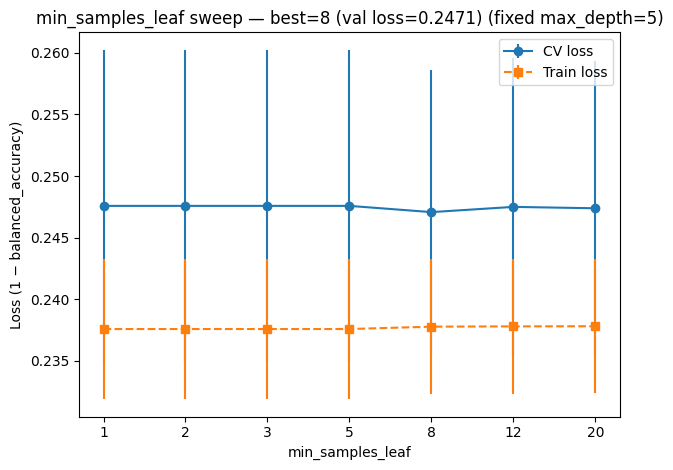

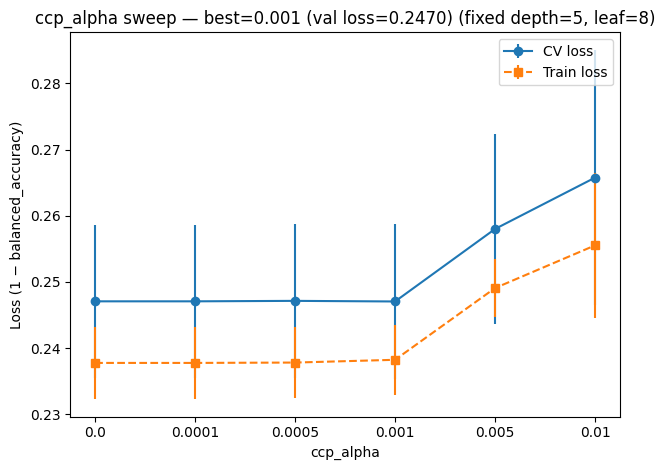


Chosen params:
  max_depth        = 5
  min_samples_leaf = 8
  ccp_alpha        = 0.001

Final 5-fold CV: balanced_accuracy=0.7530, log_loss=0.4933


In [55]:
#Decision Tree (Classification): One-Parameter-at-a-Time tuning on support2_imputed.csv
#Target: 3rd column from the RIGHT (use df.columns[-3]); expected binary (death)
#Selection metric: balanced_accuracy (plots loss = 1 − balanced_accuracy)
#Reports log_loss
#Order: max_depth -> min_samples_leaf -> ccp_alpha
#Numeric casting & NaN handling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, validation_curve, cross_val_score
from sklearn.tree import DecisionTreeClassifier

#setup
csv_path    = "support2_imputed.csv" 
random_seed = 42
n_splits    = 5                        
n_jobs      = 1                        

# Load & choose target 
df = pd.read_csv(csv_path)
target_col = df.columns[-3]         #3rd from right
print("Using target column (3rd from right):", target_col)

#binary 0/1
y = pd.to_numeric(df[target_col], errors="coerce").astype(int).values
X = df.drop(columns=[target_col])

#features numeric & handle NaNs
X = X.apply(pd.to_numeric, errors="coerce")
drop_cols = [c for c in X.columns if X[c].isna().all()]
if drop_cols:
    print("Dropping all-NaN columns:", drop_cols)
    X = X.drop(columns=drop_cols)
X = X.fillna(X.median(numeric_only=True))

#Classifier & CV
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
base = DecisionTreeClassifier(random_state=random_seed, class_weight="balanced")


#sweep with CV; plot loss = 1 − balanced_accuracy
def param_curve(estimator, X, y, *, param_name, param_values, scoring, cv, title_note=""):
    tr_scores, va_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_values,
        scoring=scoring,   
        cv=cv,
        n_jobs=n_jobs
    )
    tr_mean, va_mean = tr_scores.mean(axis=1), va_scores.mean(axis=1)
    tr_std,  va_std  = tr_scores.std(axis=1), va_scores.std(axis=1)

    tr_loss = 1.0 - tr_mean
    va_loss = 1.0 - va_mean

    best_idx   = int(np.argmin(va_loss))
    best_param = param_values[best_idx]
    best_loss  = float(va_loss[best_idx])

    # Plot
    plt.figure()
    x = np.arange(len(param_values))
    plt.errorbar(x, va_loss, yerr=va_std, fmt="o-", label="CV loss")
    plt.errorbar(x, tr_loss, yerr=tr_std, fmt="s--", label="Train loss")
    plt.xticks(x, [str(v) for v in param_values])
    plt.xlabel(param_name)
    plt.ylabel("Loss (1 − balanced_accuracy)")
    plt.title(f"{param_name} sweep — best={best_param} (val loss={best_loss:.4f}) {title_note}")
    plt.legend(); plt.tight_layout(); plt.show()

    return best_param

#Tune max_depth
depth_values = [3, 5, 7, 9, 12, 15, 20]
best_depth = param_curve(
    base, X, y,
    param_name="max_depth",
    param_values=depth_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note=f"[target: {target_col}]"
)

#Tune min_samples_leaf (fix depth)
leaf_values = [1, 2, 3, 5, 8, 12, 20]
best_leaf = param_curve(
    base.set_params(max_depth=best_depth), X, y,
    param_name="min_samples_leaf",
    param_values=leaf_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note=f"(fixed max_depth={best_depth})"
)

#Tune ccp_alpha (post-pruning) last
alpha_values = [0.0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
best_alpha = float(param_curve(
    base.set_params(max_depth=best_depth, min_samples_leaf=best_leaf), X, y,
    param_name="ccp_alpha",
    param_values=alpha_values,
    scoring="balanced_accuracy",
    cv=cv,
    title_note=f"(fixed depth={best_depth}, leaf={best_leaf})"
))
best_alpha = max(0.0, best_alpha)

# Final cross-validated metrics
final = base.set_params(
    max_depth=int(best_depth) if best_depth is not None else None,
    min_samples_leaf=int(best_leaf),
    ccp_alpha=best_alpha
)

ba = cross_val_score(final, X, y, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs).mean()
logloss = -cross_val_score(final, X, y, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs).mean()

print("\nChosen params:")
print(f"  max_depth        = {best_depth}")
print(f"  min_samples_leaf = {best_leaf}")
print(f"  ccp_alpha        = {best_alpha}")
print(f"\nFinal {n_splits}-fold CV: balanced_accuracy={ba:.4f}, log_loss={logloss:.4f}")

In [56]:
#decision tree (classification): grid search
#dataset: support2_imputed.csv
#target: 3rd column from the right (binary death)
#metrics: balanced_accuracy (primary), log_loss (secondary)
#3-fold cv, compact grid, parallel jobs, pruning-path alphas

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score
)

#setup
csv_path    = "support2_imputed.csv"
random_seed = 42
n_splits    = 3
n_jobs      = -1

# load & prep data
df = pd.read_csv(csv_path)
target_col = df.columns[-3]   # 3rd from right = death
print("using target column (3rd from right):", target_col)

y_full = pd.to_numeric(df[target_col], errors="coerce").astype(int).values
X_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")

# drop all-nan columns and fill remaining nans
drop_cols = [c for c in X_full.columns if X_full[c].isna().all()]
if drop_cols:
    print("dropping all-nan columns:", drop_cols)
    X_full = X_full.drop(columns=drop_cols)
X_full = X_full.fillna(X_full.median(numeric_only=True)).astype("float32")

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
# build pruning alphas
n = len(X_full)
m = min(10000, max(4, n))  
rng = np.random.RandomState(random_seed)
idx = rng.choice(n, size=m, replace=False)

X_alpha = X_full.iloc[idx]
y_alpha = y_full[idx]

tmp_clf = DecisionTreeClassifier(random_state=random_seed, class_weight="balanced")
path = tmp_clf.cost_complexity_pruning_path(X_alpha, y_alpha)
alpha_candidates = np.unique(np.round(path.ccp_alphas, 7))

if len(alpha_candidates) > 20:
    qs = np.linspace(0.05, 0.95, 20)
    alpha_candidates = np.unique(np.quantile(alpha_candidates, qs))

alpha_candidates = [float(a) for a in alpha_candidates if np.isfinite(a)]
if len(alpha_candidates) == 0:
    alpha_candidates = [0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

print(f"using {len(alpha_candidates)} ccp_alpha candidates from pruning path")

# grid focused on overfitting control
param_grid = {
    "max_depth":        [3, 5, 7, 9],
    "min_samples_leaf": [1, 2, 5, 8, 12],
    "ccp_alpha":        alpha_candidates
}

clf = DecisionTreeClassifier(random_state=random_seed, class_weight="balanced")

scoring = {"ba": "balanced_accuracy", "logloss": "neg_log_loss"}

gs = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring=scoring,
    refit="ba",
    cv=cv,
    n_jobs=n_jobs,
    verbose=1
)

gs.fit(X_full, y_full)

#top 10 by balanced_accuracy
cvres = pd.DataFrame(gs.cv_results_).copy()
cvres["mean_ba"]      = cvres["mean_test_ba"]
cvres["std_ba"]       = cvres["std_test_ba"]
cvres["mean_logloss"] = -cvres["mean_test_logloss"]
cvres["std_logloss"]  =  cvres["std_test_logloss"]

cols = [
    "rank_test_ba", "mean_ba", "std_ba", "mean_logloss", "std_logloss",
    "param_max_depth", "param_min_samples_leaf", "param_ccp_alpha"
]
cvres_sorted = cvres.sort_values("rank_test_ba").reset_index(drop=True)
top10 = cvres_sorted.loc[:9, cols]

print("\n top 10 parameter sets (by balanced_accuracy):")
print(top10.to_string(index=False))

#final cv metrics on full data with best params
best_params = gs.best_params_
print("\n best params (by cv balanced_accuracy):", best_params)

best_tree = DecisionTreeClassifier(
    random_state=random_seed, class_weight="balanced", **best_params
)

ba_full = cross_val_score(
    best_tree, X_full, y_full, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs
).mean()
logloss_full = -cross_val_score(
    best_tree, X_full, y_full, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs
).mean()

print(f"\n final {n_splits}-fold cv on full data -> balanced_accuracy={ba_full:.4f}, log_loss={logloss_full:.4f}")



using target column (3rd from right): death
dropping all-nan columns: ['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']
using 20 ccp_alpha candidates from pruning path
Fitting 3 folds for each of 400 candidates, totalling 1200 fits

 top 10 parameter sets (by balanced_accuracy):
 rank_test_ba  mean_ba   std_ba  mean_logloss  std_logloss  param_max_depth  param_min_samples_leaf  param_ccp_alpha
            1 0.754036 0.005286      0.493884     0.003951                5                       8         0.000799
            1 0.754036 0.005286      0.493884     0.003951                5                      12         0.000799
            3 0.754004 0.005143      0.493437     0.004052                5                       8         0.000154
            3 0.754004 0.005143      0.493437     0.004052                5                       8         0.000118
            3 0.754004 0.005143      0.493585     0.003984                5                       8         0.00021

**Decision tree summary for SUPPORT2:** The tuned decision tree provides a baseline classification model for predicting mortality in the SUPPORT2 dataset. Balanced accuracy and log loss are used to compare model discrimination and probability quality.

## Diabetes Dataset: Random Forest Classification

This section applies random forest classification to the diabetes dataset. Random forests are tested to evaluate whether an ensemble of decision trees improves classification performance compared with a single decision tree.

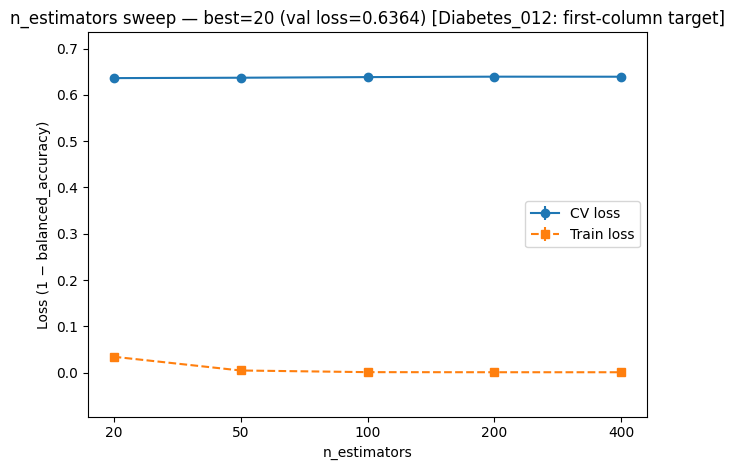

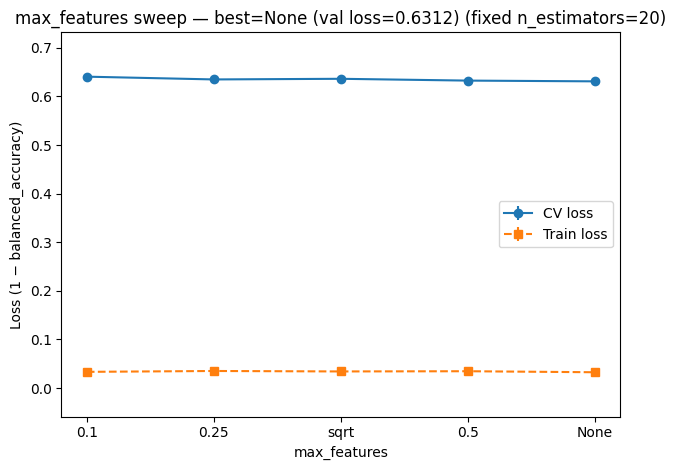

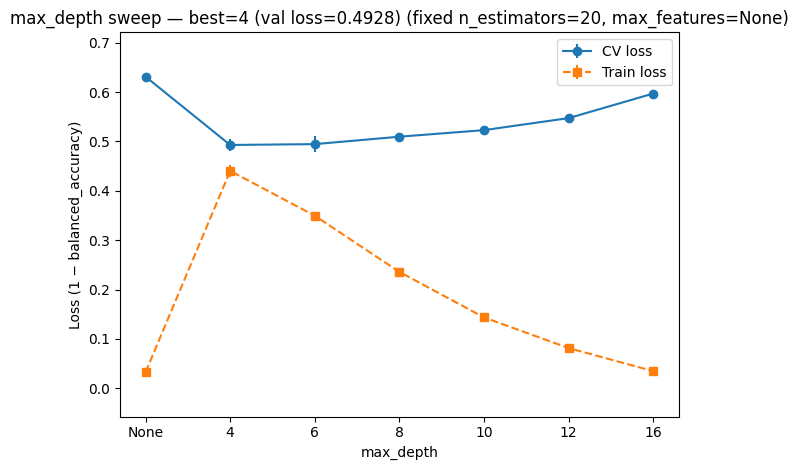

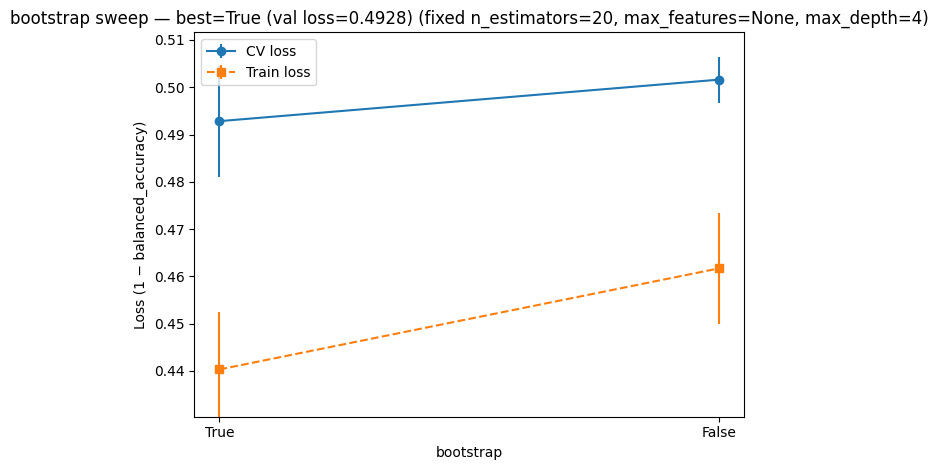


Chosen RF parameters (FAST):
  n_estimators = 20
  max_features = None
  max_depth    = 4
  bootstrap    = True

Final 3-fold CV on FULL data: balanced_accuracy=0.4985, log_loss=0.9044


In [57]:
#Random Forest (Classification)
#Dataset: BRFSS Diabetes_012--first column is target)
#Metric: balanced_accuracy (plots loss = 1 - balanced_accuracy)
#3-fold CV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, validation_curve, cross_val_score, train_test_split

#Fast preset
csv_path    = "diabetes_012_health_indicators_BRFSS2015.csv"
random_seed = 42
n_splits    = 3          # fast CV
n_jobs_cv   = -1        
subsample   = True       # subsample for sweeps
sub_rows    = 20000      # subsample size for sweeps

#Small numbers needed for speed
n_est_values    = [20, 50, 100, 200, 400]
max_feat_values = [0.1, 0.25, "sqrt", 0.5, None]
max_depth_vals  = [None, 4, 6, 8, 10, 12, 16]
bootstrap_vals  = [True, False]   

#Load and prep data
df = pd.read_csv(csv_path)
target_col = df.columns[0]               # first column is the label
y_full = df[target_col].astype(int).values
X_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")
if X_full.isna().any().any():
    X_full = X_full.fillna(X_full.median(numeric_only=True))

# subsample for sweeps: final CV uses full data
if subsample and len(X_full) > sub_rows:
    X, _, y, _ = train_test_split(
        X_full, y_full, train_size=sub_rows, stratify=y_full, random_state=random_seed
    )
else:
    X, y = X_full, y_full

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

base = RandomForestClassifier(
    random_state=random_seed,
    class_weight="balanced_subsample",
    n_jobs=-1,          
    criterion="gini",
)

#Helper
def param_curve(estimator, X, y, *, param_name, param_values, cv, title_note="", zoom=True):
    tr_scores, va_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_values,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=n_jobs_cv
    )
    tr_mean, va_mean = tr_scores.mean(axis=1), va_scores.mean(axis=1)
    tr_std,  va_std  = tr_scores.std(axis=1),  va_scores.std(axis=1)

    tr_loss = 1.0 - tr_mean
    va_loss = 1.0 - va_mean

    best_idx   = int(np.argmin(va_loss))
    best_param = param_values[best_idx]
    best_loss  = float(va_loss[best_idx])

    # Plot
    plt.figure()
    x = np.arange(len(param_values))
    plt.errorbar(x, va_loss, yerr=va_std, fmt="o-", label="CV loss")
    plt.errorbar(x, tr_loss, yerr=tr_std, fmt="s--", label="Train loss")
    plt.xticks(x, [str(v) for v in param_values])
    plt.xlabel(param_name)
    plt.ylabel("Loss (1 − balanced_accuracy)")
    plt.title(f"{param_name} sweep — best={best_param} (val loss={best_loss:.4f}) {title_note}")

    #curves aren't flat
    if zoom:
        lo = min(va_loss.min(), tr_loss.min())
        hi = max(va_loss.max(), tr_loss.max())
        pad = max((hi - lo) * 0.15, 0.01)   # at least 0.01 span
        plt.ylim(lo - pad, hi + pad)

    plt.legend()
    plt.tight_layout()
    plt.show()

    return best_param

#n_estimators
best_n_estimators = param_curve(
    base, X, y,
    param_name="n_estimators",
    param_values=n_est_values,
    cv=cv,
    title_note="[Diabetes_012: first-column target]"
)

#max_features (fixed n_estimators)
rf_n = base.set_params(n_estimators=best_n_estimators)
best_max_features = param_curve(
    rf_n, X, y,
    param_name="max_features",
    param_values=max_feat_values,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators})"
)

#max_depth (fix prior)
rf_nm = rf_n.set_params(max_features=best_max_features)
best_max_depth = param_curve(
    rf_nm, X, y,
    param_name="max_depth",
    param_values=max_depth_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features})"
)

#bootstrap (fix prior) — True vs False plot
rf_nmd = rf_nm.set_params(max_depth=best_max_depth)
best_bootstrap = param_curve(
    rf_nmd, X, y,
    param_name="bootstrap",
    param_values=bootstrap_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features}, max_depth={best_max_depth})"
)

#Final model & report
final_rf = base.set_params(
    n_estimators=best_n_estimators,
    max_features=best_max_features,
    max_depth=best_max_depth,
    bootstrap=bool(best_bootstrap)
)

ba = cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs_cv).mean()
logloss = -cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs_cv).mean()

print("\nChosen RF parameters (FAST):")
print(f"  n_estimators = {best_n_estimators}")
print(f"  max_features = {best_max_features}")
print(f"  max_depth    = {best_max_depth}")
print(f"  bootstrap    = {best_bootstrap}")
print(f"\nFinal {n_splits}-fold CV on FULL data: balanced_accuracy={ba:.4f}, log_loss={logloss:.4f}")

In [58]:
# Fast Random Forest search: Randomized, tiny Grid (Diabetes_012)
# Target: first column. Metric: balanced_accuracy (also report log_loss).

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     RandomizedSearchCV, GridSearchCV)
from sklearn.metrics import make_scorer
from scipy.stats import randint

#setup
csv_path    = "diabetes_012_health_indicators_BRFSS2015.csv"
random_seed = 42
n_splits    = 3          
n_jobs      = -1        
sub_rows    = 20000      

#Load data
df = pd.read_csv(csv_path)
y_full = df.iloc[:, 0].astype(int).values
X_full = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").fillna(
    df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").median(numeric_only=True)
)

# Subsample for the search (final model refits on full data)
if len(X_full) > sub_rows:
    X_s, _, y_s, _ = train_test_split(X_full, y_full, train_size=sub_rows,
                                      stratify=y_full, random_state=random_seed)
else:
    X_s, y_s = X_full, y_full

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed)

#Base model
rf = RandomForestClassifier(
    random_state=random_seed,
    class_weight="balanced_subsample",
    n_jobs=-1,
    n_estimators=150
)

#RandomizedSearchCV
rand_param_dist = {
    "n_estimators": randint(50, 250),           
    "max_features": ["sqrt", 0.25, 0.5, None],
    "max_depth":    [None, 5, 7, 10, 12, 15],
    "bootstrap":    [True, False],
}

rand = RandomizedSearchCV(
    rf,
    param_distributions=rand_param_dist,
    n_iter=24,                   
    scoring={"ba": "balanced_accuracy", "logloss": "neg_log_loss"},
    refit="ba",
    cv=cv,
    n_jobs=n_jobs,
    verbose=1,
    random_state=random_seed,
)
rand.fit(X_s, y_s)
print("\n[Randomized] best params:", rand.best_params_)
print("[Randomized] best CV balanced_accuracy:", rand.best_score_)

best = rand.best_params_

def around(value, options):
    vals = list(dict.fromkeys(options))
    return vals

grid = {
    "n_estimators": around(best["n_estimators"], [
        max(50, best["n_estimators"]//2),
        best["n_estimators"],
        min(400, best["n_estimators"]*2),
    ]),
    "max_features": around(best["max_features"], [
        best["max_features"], "sqrt", 0.25, 0.5, None
    ]),
    "max_depth": around(best["max_depth"], [
        None if best["max_depth"] is None else max(3, best["max_depth"]-2),
        best["max_depth"],
        None if best["max_depth"] is None else best["max_depth"]+2
    ]),
    "bootstrap": [True, False],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=random_seed,
                           class_weight="balanced_subsample", n_jobs=-1),
    param_grid=grid,
    scoring={"ba": "balanced_accuracy", "logloss": "neg_log_loss"},
    refit="ba",
    cv=cv,
    n_jobs=n_jobs,
    verbose=1,
)
gs.fit(X_s, y_s)
print("\n[Grid(local)] best params:", gs.best_params_)
print("[Grid(local)] best CV balanced_accuracy:", gs.best_score_)

#Final refit on full data 
final_params = gs.best_params_.copy()
final_params["n_estimators"] = max(300, final_params["n_estimators"]) 

final_rf = RandomForestClassifier(
    random_state=random_seed, class_weight="balanced_subsample", n_jobs=-1, **final_params
)
final_rf.fit(X_full, y_full)   

# Cross-validated report on full data
from sklearn.model_selection import cross_val_score
ba = cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs).mean()
logloss = -cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs).mean()

print("\n[FINAL] params:", final_params)
print(f"[FINAL] {n_splits}-fold CV on FULL data -> balanced_accuracy={ba:.4f}, log_loss={logloss:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits

[Randomized] best params: {'bootstrap': False, 'max_depth': 5, 'max_features': 0.25, 'n_estimators': 138}
[Randomized] best CV balanced_accuracy: 0.5190143262510403
Fitting 3 folds for each of 72 candidates, totalling 216 fits

[Grid(local)] best params: {'bootstrap': True, 'max_depth': 5, 'max_features': 0.25, 'n_estimators': 69}
[Grid(local)] best CV balanced_accuracy: 0.521663128925702

[FINAL] params: {'bootstrap': True, 'max_depth': 5, 'max_features': 0.25, 'n_estimators': 300}
[FINAL] 3-fold CV on FULL data -> balanced_accuracy=0.5109, log_loss=0.8938


**Random forest summary for diabetes:** The random forest models provide an ensemble-based comparison against the earlier decision tree results. Balanced accuracy remains the main metric because of the imbalanced diabetes outcome classes.

## Life Expectancy Dataset: Random Forest Regression

This section applies random forest regression to the life expectancy dataset. The model is tuned using the number of trees, maximum features, maximum depth, and bootstrap settings.

Using target column: Life expectancy 
Dropping all-NaN columns: ['Country', 'Status']


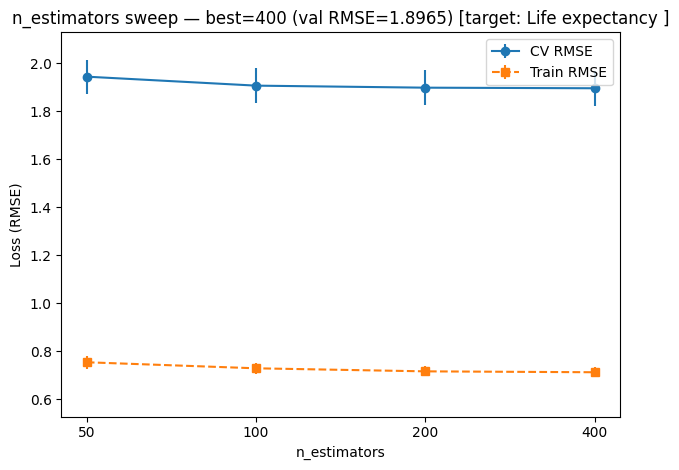

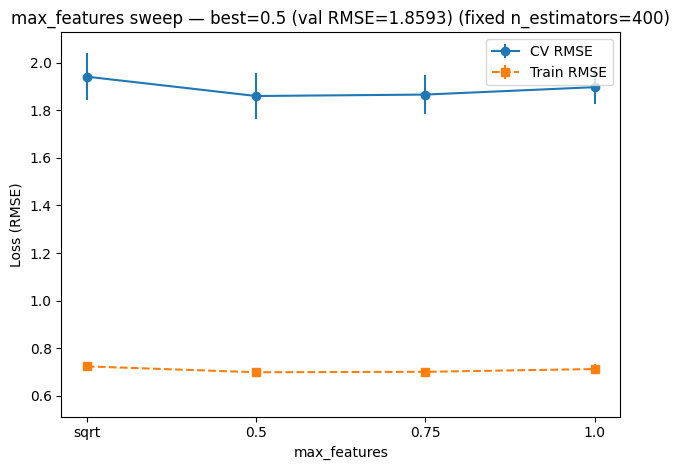

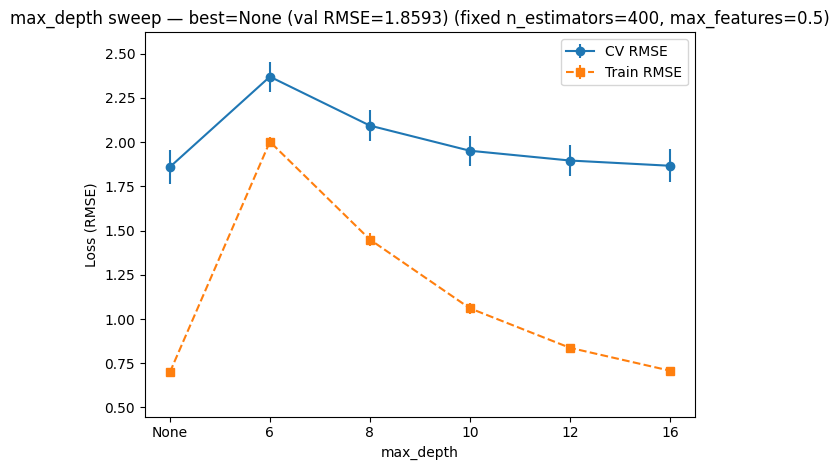

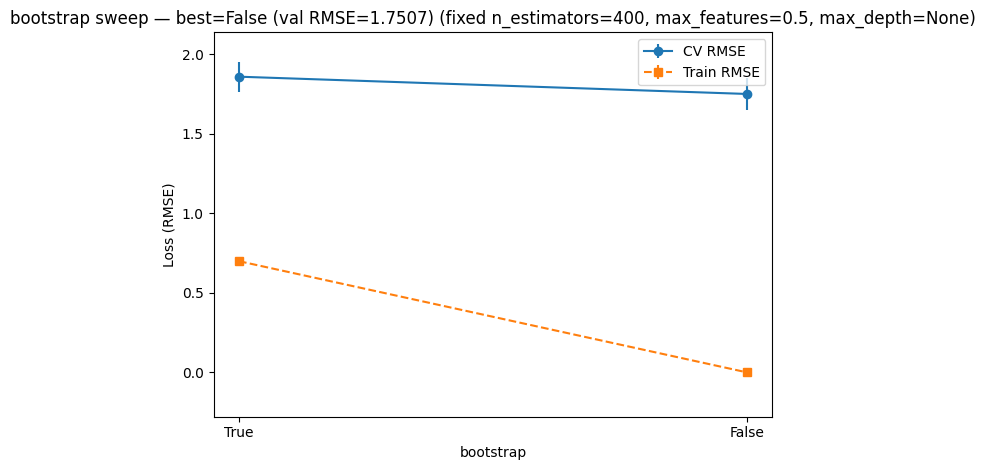


Chosen RF (Regression) parameters:
  n_estimators = 400
  max_features = 0.5
  max_depth    = None
  bootstrap    = False

Final 3-fold CV on FULL data: RMSE=1.7507, MAE=1.0434


In [60]:

# Random Forest (Regression) - tuning with RMSE loss plots
# Dataset: Life Expectancy (imputed) — target is the 4th column (column D)
# Metric: RMSE via "neg_root_mean_squared_error" (plot positive RMSE = loss)
# Speed: 3-fold CV, modest grids, parallel CV, and subsample for sweeps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, validation_curve, cross_val_score, train_test_split

#setup
csv_path    = "Life Expectancy Data - mean_mode_imputed.csv"
Random_Seed = 42
N_Splits    = 3           
N_Jobs_CV   = -1         
Subsample   = False      
Sub_Rows    = 20000      

#ranges
n_est_values    = [50, 100, 200, 400]           
max_feat_values = ["sqrt", 0.5, 0.75, 1.0]     
max_depth_vals  = [None, 6, 8, 10, 12, 16]     
bootstrap_vals  = [True, False]               

#load and set target (column D)
df = pd.read_csv(csv_path)
Target_COL = df.columns[3]          #4th column
print("Using target column:", Target_COL)

y_full = pd.to_numeric(df[Target_COL], errors="coerce").values
X_full = df.drop(columns=[Target_COL]).apply(pd.to_numeric, errors="coerce")

drop_cols = [c for c in X_full.columns if X_full[c].isna().all()]
if drop_cols:
    print("Dropping all-NaN columns:", drop_cols)
    X_full = X_full.drop(columns=drop_cols)
X_full = X_full.fillna(X_full.median(numeric_only=True))

if Subsample and len(X_full) > Sub_Rows:
    X, _, y, _ = train_test_split(X_full, y_full, train_size=Sub_Rows, random_state=Random_Seed)
else:
    X, y = X_full, y_full

cv = KFold(n_splits=N_Splits, shuffle=True, random_state=Random_Seed)

base = RandomForestRegressor(
    random_state=Random_Seed,
    n_jobs=-1,                 # parallelize trees
    criterion="squared_error", # default
)

#sweep and plot (Loss = RMSE)
def param_curve(estimator, X, y, *, param_name, param_values, cv, title_note="", zoom=True):
    tr_scores, va_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_values,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=N_Jobs_CV
    )
    # Convert "neg RMSE" to positive RMSE (loss)
    tr_rmse = -tr_scores.mean(axis=1)
    va_rmse = -va_scores.mean(axis=1)
    tr_std  =  tr_scores.std(axis=1)
    va_std  =  va_scores.std(axis=1)

    best_idx   = int(np.argmin(va_rmse))
    best_param = param_values[best_idx]
    best_loss  = float(va_rmse[best_idx])

    # Plot
    plt.figure()
    x = np.arange(len(param_values))
    plt.errorbar(x, va_rmse, yerr=va_std, fmt="o-", label="CV RMSE")
    plt.errorbar(x, tr_rmse, yerr=tr_std, fmt="s--", label="Train RMSE")
    plt.xticks(x, [str(v) for v in param_values])
    plt.xlabel(param_name)
    plt.ylabel("Loss (RMSE)")
    plt.title(f"{param_name} sweep — best={best_param} (val RMSE={best_loss:.4f}) {title_note}")

    if zoom:
        lo = min(va_rmse.min(), tr_rmse.min())
        hi = max(va_rmse.max(), tr_rmse.max())
        pad = max((hi - lo) * 0.15, 0.01)
        plt.ylim(lo - pad, hi + pad)

    plt.legend(); plt.tight_layout(); plt.show()
    return best_param

#n_estimators
best_n_estimators = param_curve(
    base, X, y,
    param_name="n_estimators",
    param_values=n_est_values,
    cv=cv,
    title_note=f"[target: {Target_COL}]"
)

#max_features (fix n_estimators)
rf_n = base.set_params(n_estimators=best_n_estimators)
best_max_features = param_curve(
    rf_n, X, y,
    param_name="max_features",
    param_values=max_feat_values,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators})"
)

#max_depth (fix prior)
rf_nm = rf_n.set_params(max_features=best_max_features)
best_max_depth = param_curve(
    rf_nm, X, y,
    param_name="max_depth",
    param_values=max_depth_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features})"
)

# bootstrap (fix prior): True vs False
rf_nmd = rf_nm.set_params(max_depth=best_max_depth)
best_bootstrap = param_curve(
    rf_nmd, X, y,
    param_name="bootstrap",
    param_values=bootstrap_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features}, max_depth={best_max_depth})"
)

#Final model and report
final_rf = base.set_params(
    n_estimators=best_n_estimators,
    max_features=best_max_features,
    max_depth=best_max_depth,
    bootstrap=bool(best_bootstrap)
)

rmse = -cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=N_Jobs_CV).mean()
mae  = -cross_val_score(final_rf, X_full, y_full, cv=cv, scoring="neg_mean_absolute_error",   n_jobs=N_Jobs_CV).mean()

print("\nChosen RF (Regression) parameters:")
print(f"  n_estimators = {best_n_estimators}")
print(f"  max_features = {best_max_features}")
print(f"  max_depth    = {best_max_depth}")
print(f"  bootstrap    = {best_bootstrap}")
print(f"\nFinal {N_Splits}-fold CV on FULL data: RMSE={rmse:.4f}, MAE={mae:.4f}")

In [61]:
# random forest (regression): grid search for life expectancy (imputed)
# target: 4th column (column d)
# metric: rmse via "neg_root_mean_squared_error"
# 3-fold cv, small grid, parallel jobs, subsample for the search

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split

# configure
csv_path      = "Life Expectancy Data - mean_mode_imputed.csv"
random_seed   = 42
n_splits      = 3          
n_jobs        = -1         
use_subsample = True       
sub_rows      = 20000      

# small grid
param_grid = {
    "n_estimators": [100, 200, 300],        
    "max_features": ["sqrt", 0.5, 1.0],      
    "max_depth":    [None, 8, 12],           
    "bootstrap":    [True, False],
}

# load and set target (column d)
df = pd.read_csv(csv_path)
target_col = df.columns[3]   
print("using target column:", target_col)

y_full = pd.to_numeric(df[target_col], errors="coerce").values
X_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")

#drop all-nan columns, then median-fill
drop_cols = [c for c in X_full.columns if X_full[c].isna().all()]
if drop_cols:
    print("dropping all-nan columns:", drop_cols)
    X_full = X_full.drop(columns=drop_cols)
X_full = X_full.fillna(X_full.median(numeric_only=True)).astype("float32")

#subsample for the grid search: final cv on full data
if use_subsample and len(X_full) > sub_rows:
    X_s, _, y_s, _ = train_test_split(
        X_full, y_full, train_size=sub_rows, random_state=random_seed
    )
else:
    X_s, y_s = X_full, y_full

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

# grid search
rf = RandomForestRegressor(
    random_state=random_seed,
    n_jobs=-1,                  
    criterion="squared_error"
)

gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  
    refit=True,                              
    cv=cv,
    n_jobs=n_jobs,
    verbose=1
)

gs.fit(X_s, y_s)


cvres = pd.DataFrame(gs.cv_results_).copy()
cvres["mean_rmse"] = -cvres["mean_test_score"]   
cvres["std_rmse"]  =  cvres["std_test_score"]
cols = [
    "rank_test_score", "mean_rmse", "std_rmse",
    "param_n_estimators", "param_max_features", "param_max_depth", "param_bootstrap"
]
cvres_sorted = cvres.sort_values("rank_test_score").reset_index(drop=True)
top10 = cvres_sorted.loc[:9, cols]

print("\n top 10 parameter sets (by cv rmse):")
print(top10.to_string(index=False))

# save
cvres_sorted.to_csv("rf_grid_results_lifeexp_light.csv", index=False)
print("\n saved full grid results to rf_grid_results_lifeexp_light.csv")

# final evaluation on full data with best params
best_params = gs.best_params_
print("\n best params (by cv rmse):", best_params)

best_rf = RandomForestRegressor(random_state=random_seed, n_jobs=-1, **best_params)

rmse_full = -cross_val_score(
    best_rf, X_full, y_full, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=n_jobs
).mean()
mae_full  = -cross_val_score(
    best_rf, X_full, y_full, cv=cv, scoring="neg_mean_absolute_error", n_jobs=n_jobs
).mean()

print(f"\n final {n_splits}-fold cv on full data -> rmse={rmse_full:.4f}, mae={mae_full:.4f}")

using target column: Life expectancy 
dropping all-nan columns: ['Country', 'Status']
Fitting 3 folds for each of 54 candidates, totalling 162 fits

 top 10 parameter sets (by cv rmse):
 rank_test_score  mean_rmse  std_rmse  param_n_estimators param_max_features param_max_depth  param_bootstrap
               1   1.747746  0.101881                 300                0.5            None            False
               2   1.749594  0.100294                 200                0.5            None            False
               3   1.757927  0.096712                 100                0.5            None            False
               4   1.793301  0.108901                 300                0.5              12            False
               5   1.798315  0.107370                 200                0.5              12            False
               6   1.801012  0.092722                 200               sqrt            None            False
               7   1.804360  0.093034       

**Random forest summary for life expectancy:** The random forest regression model is evaluated with RMSE and MAE. The ensemble approach is used to compare whether multiple trees improve prediction accuracy over a single decision tree.

## SUPPORT2 Dataset: Random Forest Classification

This section applies random forest classification to the SUPPORT2 dataset using death as the target outcome. The workflow compares hyperparameter settings for tree count, feature selection, depth, and bootstrap sampling.

using target column (3rd from right): death
dropping all-nan columns: ['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']


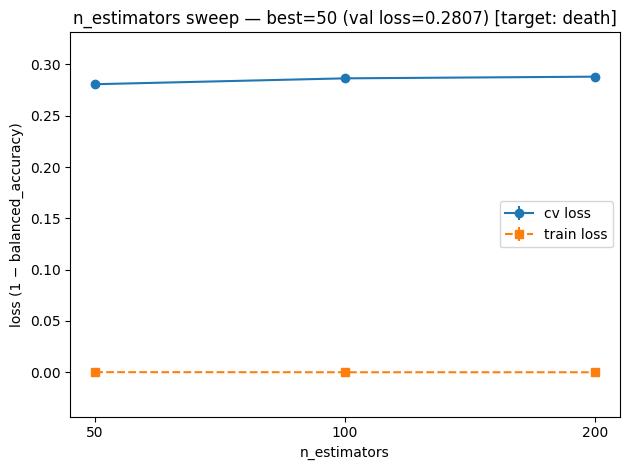

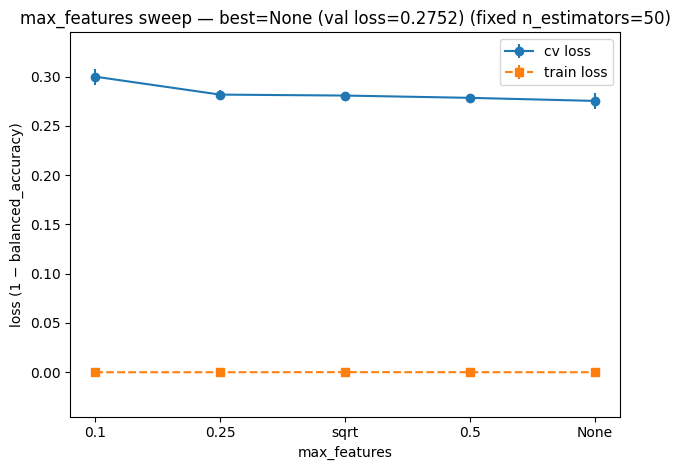

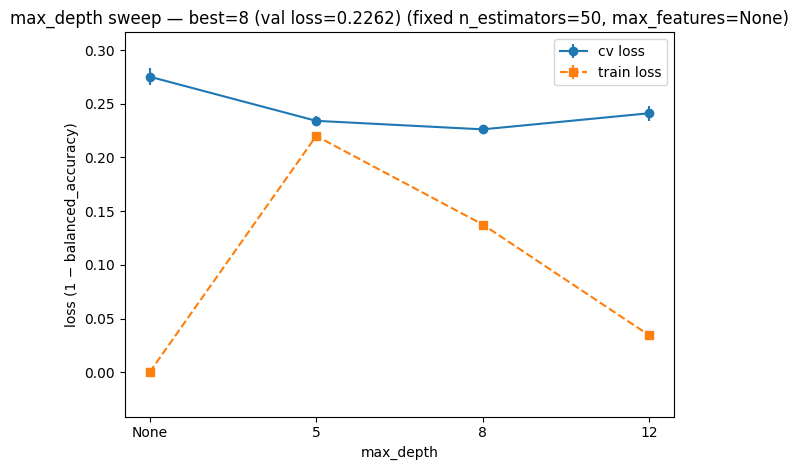

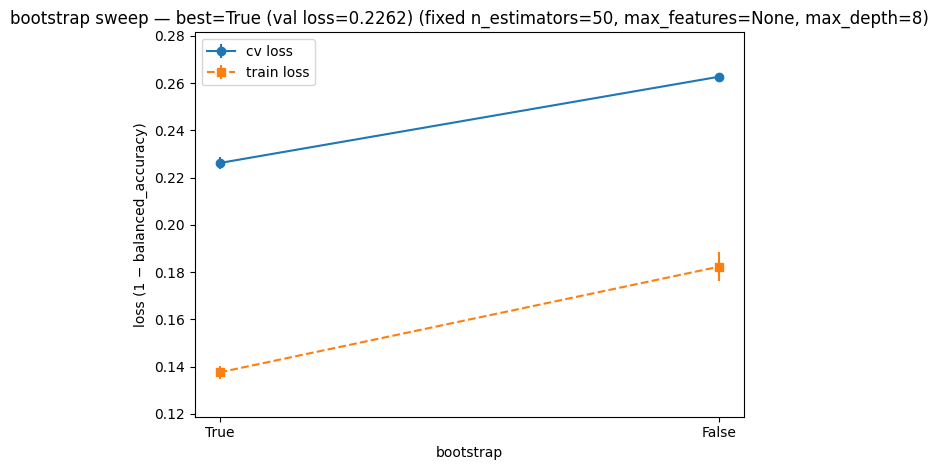


chosen rf parameters (fast):
  n_estimators = 50
  max_features = None
  max_depth    = 8
  bootstrap    = True

final 3-fold cv on full data: balanced_accuracy=0.7738, log_loss=0.4398


In [62]:
# random forest (classification) 
# dataset: support2_imputed.csv
# target: 3rd column from right (aq) binary death
# metric: balanced_accuracy (plots loss = 1 - balanced_accuracy)
# 3-fold cv, good ranges, parallel cv, subsample for sweeps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier as rf_classifier
from sklearn.model_selection import StratifiedKFold as skf, validation_curve, cross_val_score, train_test_split

#setup
csv_path   = "support2_imputed.csv"
random_seed = 42
n_splits    = 3
n_jobs_cv   = -1
subsample   = True
sub_rows    = 20000

#good ranges
n_est_values    = [50, 100, 200]
max_feat_values = [0.1, 0.25, "sqrt", 0.5, None]
max_depth_vals  = [None, 5, 8, 12]
bootstrap_vals  = [True, False]

#load and target (3rd from right)
df = pd.read_csv(csv_path)
target_col = df.columns[-3]
print("using target column (3rd from right):", target_col)

y_full = pd.to_numeric(df[target_col], errors="coerce").astype(int).values
x_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")

#drop all-nan cols, fill remaining nans
drop_cols = [c for c in x_full.columns if x_full[c].isna().all()]
if drop_cols:
    print("dropping all-nan columns:", drop_cols)
    x_full = x_full.drop(columns=drop_cols)
x_full = x_full.fillna(x_full.median(numeric_only=True)).astype("float32")

#subsample for sweeps
if subsample and len(x_full) > sub_rows:
    x, _, y, _ = train_test_split(
        x_full, y_full, train_size=sub_rows, stratify=y_full, random_state=random_seed
    )
else:
    x, y = x_full, y_full

cv = skf(n_splits=n_splits, shuffle=True, random_state=random_seed)

base = rf_classifier(
    random_state=random_seed,
    class_weight="balanced_subsample",
    n_jobs=-1,
    criterion="gini"
)

#helper
def param_curve(estimator, x, y, *, param_name, param_values, cv, title_note="", zoom=True):
    tr_scores, va_scores = validation_curve(
        estimator, x, y,
        param_name=param_name,
        param_range=param_values,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=n_jobs_cv
    )
    tr_mean, va_mean = tr_scores.mean(axis=1), va_scores.mean(axis=1)
    tr_std,  va_std  = tr_scores.std(axis=1),  va_scores.std(axis=1)

    tr_loss = 1.0 - tr_mean
    va_loss = 1.0 - va_mean

    best_idx   = int(np.argmin(va_loss))
    best_param = param_values[best_idx]
    best_loss  = float(va_loss[best_idx])

    plt.figure()
    xaxis = np.arange(len(param_values))
    plt.errorbar(xaxis, va_loss, yerr=va_std, fmt="o-", label="cv loss")
    plt.errorbar(xaxis, tr_loss, yerr=tr_std, fmt="s--", label="train loss")
    plt.xticks(xaxis, [str(v) for v in param_values])
    plt.xlabel(param_name)
    plt.ylabel("loss (1 − balanced_accuracy)")
    plt.title(f"{param_name} sweep — best={best_param} (val loss={best_loss:.4f}) {title_note}")

    if zoom:
        lo = min(va_loss.min(), tr_loss.min())
        hi = max(va_loss.max(), tr_loss.max())
        pad = max((hi - lo) * 0.15, 0.01)
        plt.ylim(lo - pad, hi + pad)

    plt.legend(); plt.tight_layout(); plt.show()
    return best_param

#n_estimators
best_n_estimators = param_curve(
    base, x, y,
    param_name="n_estimators",
    param_values=n_est_values,
    cv=cv,
    title_note=f"[target: {target_col}]"
)

#max_features (fix n_estimators)
rf_n = base.set_params(n_estimators=best_n_estimators)
best_max_features = param_curve(
    rf_n, x, y,
    param_name="max_features",
    param_values=max_feat_values,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators})"
)

#max_depth (fix prior)
rf_nm = rf_n.set_params(max_features=best_max_features)
best_max_depth = param_curve(
    rf_nm, x, y,
    param_name="max_depth",
    param_values=max_depth_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features})"
)

#bootstrap (fix prior): true vs false plot
rf_nmd = rf_nm.set_params(max_depth=best_max_depth)
best_bootstrap = param_curve(
    rf_nmd, x, y,
    param_name="bootstrap",
    param_values=bootstrap_vals,
    cv=cv,
    title_note=f"(fixed n_estimators={best_n_estimators}, max_features={best_max_features}, max_depth={best_max_depth})"
)

#final model and report on full data
final_rf = base.set_params(
    n_estimators=best_n_estimators,
    max_features=best_max_features,
    max_depth=best_max_depth,
    bootstrap=bool(best_bootstrap)
)

ba = cross_val_score(final_rf, x_full, y_full, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs_cv).mean()
logloss = -cross_val_score(final_rf, x_full, y_full, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs_cv).mean()

print("\nchosen rf parameters (fast):")
print(f"  n_estimators = {best_n_estimators}")
print(f"  max_features = {best_max_features}")
print(f"  max_depth    = {best_max_depth}")
print(f"  bootstrap    = {best_bootstrap}")
print(f"\nfinal {n_splits}-fold cv on full data: balanced_accuracy={ba:.4f}, log_loss={logloss:.4f}")








In [63]:
# random forest (classification): grid search for support2_imputed
# target: 3rd column from the right-- binary death
# metrics: balanced_accuracy as primary and log loss secondary
# 3-fold cv, small grid, parallel jobs, optional subsample

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score

#setup
csv_path      = "support2_imputed.csv"
random_seed   = 42
n_splits      = 3          
n_jobs        = -1         
use_subsample = True       
sub_rows      = 20000     

#small grid
param_grid = {
    "n_estimators": [50, 100, 200],          
    "max_features": ["sqrt", 0.25, 0.5, None],
    "max_depth":    [None, 6, 8, 12],        
    "bootstrap":    [True, False],
}
#load and set target (3rd from right = df.columns[-3])
df = pd.read_csv(csv_path)
target_col = df.columns[-3]
print("using target column (3rd from right):", target_col)

y_full = pd.to_numeric(df[target_col], errors="coerce").astype(int).values
X_full = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")

#drop all-nan columns, then median-fill
drop_cols = [c for c in X_full.columns if X_full[c].isna().all()]
if drop_cols:
    print("dropping all-nan columns:", drop_cols)
    X_full = X_full.drop(columns=drop_cols)
X_full = X_full.fillna(X_full.median(numeric_only=True)).astype("float32")

#subsample for the grid search (final cv reported on full data)
if use_subsample and len(X_full) > sub_rows:
    X_s, _, y_s, _ = train_test_split(
        X_full, y_full, train_size=sub_rows, stratify=y_full, random_state=random_seed
    )
else:
    X_s, y_s = X_full, y_full

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)

# grid search
rf = RandomForestClassifier(
    random_state=random_seed,
    class_weight="balanced_subsample",
    n_jobs=-1,
    criterion="gini"
)

scoring = {"ba": "balanced_accuracy", "logloss": "neg_log_loss"}

gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit="ba",                       
    cv=cv,
    n_jobs=n_jobs,
    verbose=1
)

gs.fit(X_s, y_s)

#top 10 by balanced_accuracy
cvres = pd.DataFrame(gs.cv_results_).copy()
cvres["mean_ba"]      = cvres["mean_test_ba"]
cvres["std_ba"]       = cvres["std_test_ba"]
cvres["mean_logloss"] = -cvres["mean_test_logloss"]  # lower is better
cvres["std_logloss"]  =  cvres["std_test_logloss"]

cols = [
    "rank_test_ba", "mean_ba", "std_ba", "mean_logloss", "std_logloss",
    "param_n_estimators", "param_max_features", "param_max_depth", "param_bootstrap"
]
cvres_sorted = cvres.sort_values("rank_test_ba").reset_index(drop=True)
top10 = cvres_sorted.loc[:9, cols]

print("\n top 10 parameter sets (by balanced_accuracy):")
print(top10.to_string(index=False))

cvres_sorted.to_csv("rf_grid_results_support2_light.csv", index=False)
print("\n saved full grid results to rf_grid_results_support2_light.csv")

# final evaluation on full data 
best_params = gs.best_params_
print("\n best params (by cv balanced_accuracy):", best_params)

best_rf = RandomForestClassifier(
    random_state=random_seed, class_weight="balanced_subsample", n_jobs=-1, **best_params
)

ba_full = cross_val_score(
    best_rf, X_full, y_full, cv=cv, scoring="balanced_accuracy", n_jobs=n_jobs
).mean()
logloss_full = -cross_val_score(
    best_rf, X_full, y_full, cv=cv, scoring="neg_log_loss", n_jobs=n_jobs
).mean()

print(f"\n final {n_splits}-fold cv on full data -> balanced_accuracy={ba_full:.4f}, log_loss={logloss_full:.4f}")

using target column (3rd from right): death
dropping all-nan columns: ['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']
Fitting 3 folds for each of 96 candidates, totalling 288 fits

 top 10 parameter sets (by balanced_accuracy):
 rank_test_ba  mean_ba   std_ba  mean_logloss  std_logloss  param_n_estimators param_max_features param_max_depth  param_bootstrap
            1 0.775834 0.006946      0.461809     0.007449                  50               sqrt               8            False
            2 0.775369 0.006215      0.441103     0.009168                  50                0.5               8             True
            3 0.775171 0.008501      0.440460     0.008443                 100                0.5               8             True
            4 0.774929 0.006237      0.461081     0.007214                 200               sqrt               8            False
            5 0.774493 0.005526      0.439766     0.008357                 200                0

**Random forest summary for SUPPORT2:** The random forest classifier provides an ensemble-based model for mortality prediction. Balanced accuracy and log loss are used to assess classification performance and probability quality.

## Overall Modeling Notes

Across the three datasets, this notebook compares single decision trees with random forest models. The results help show how tree-based methods behave across both classification and regression healthcare tasks, and they provide additional modeling benchmarks for the broader project.